In [69]:
import json
import urllib.parse
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
from gensim.models import Word2Vec
import math
import numpy as np
from sklearn.manifold import TSNE


In [2]:
with open("data/tracks.idomaar", "r") as tracks:
    trackInfos = tracks.readlines()

with open("data/albums.idomaar", "r") as albums:
    albumInfo = albums.readlines()

with open("data/persons.idomaar", "r") as persons:
    personInfo = persons.readlines()

with open("data/playlist.idomaar", "r") as playlists:
    playlistInfo = playlists.readlines()

with open("data/tags.idomaar", "r") as tags:
    tagInfo = tags.readlines()

with open("data/users.idomaar", "r") as users:
    userInfo = users.readlines()

d = {
    "trackInfo": trackInfos[:10],
    "albumInfo": albumInfo[:10],
    "personInfo": personInfo[:10],
    "playlistInfo": playlistInfo[:10],
    "tagInfo": tagInfo[:10],
    "userInfo": userInfo[:10]
}

var = "trackInfo"
name = var.upper()
data = d[var]
print(name)
for info in data:
    print(info, end="")
    

TRACKINFO
track	0	-1	{"duration":-1,"playcount":4,"MBID":null,"name":"000003+Music+Instructor/_/Dj%27s+Rock+Da+House+%C3%82%E2%89%88%C3%86%E2%89%88%C3%8A01+-+Dj+Max-Pulemet+Vs.+Bomfunk+Mc%27s+-+Electro+Breakdance+party+1+%5B2000%5D+=+CD+ONE%C3%82%E2%89%88%C3%86%E2%89%88%C3%8A"}	{"artists":[{"type":"person","id":0}],"albums":[],"tags":[]}
track	1	-1	{"duration":-1,"playcount":495,"MBID":null,"name":"00-01/_/%D0%A2%D0%B5%D0%BA%D1%81%D1%82"}	{"artists":[{"type":"person","id":1}],"albums":[],"tags":[]}
track	2	-1	{"duration":-1,"playcount":2,"MBID":null,"name":"0005.+Overkill/_/Overkill"}	{"artists":[{"type":"person","id":2}],"albums":[],"tags":[]}
track	3	-1	{"duration":-1,"playcount":2,"MBID":null,"name":"000C+Tony+Dize/_/Ruleta+Rusa"}	{"artists":[{"type":"person","id":3}],"albums":[],"tags":[]}
track	4	-1	{"duration":-1,"playcount":1,"MBID":null,"name":"000+Oscarcito/_/Tumbay%E2%80%9A+(Lyrics)"}	{"artists":[{"type":"person","id":4}],"albums":[],"tags":[]}
track	5	-1	{"duration":-1,"play

In [ ]:
idToArtistSong = {}
for trackInfo in trackInfos:
    trackId = str(trackInfo.split("\t")[1])
    jsonTrack = trackInfo.split("\t")[3]
    trackUrl = json.loads(jsonTrack)
    trackName = trackUrl["name"]
    artistSongInfo = trackName.split("/_/")
    artist = urllib.parse.unquote_plus(artistSongInfo[0])
    song = urllib.parse.unquote_plus(artistSongInfo[1])
    artist_song = artist.lower() + "__" + song.lower()
    artist_song = re.sub(r'[^\w\s\-\'\_]', '', artist_song)
    
    idToArtistSong[trackId] = artist_song

In [ ]:
for k, v in list(idToArtistSong.items())[:21]:
    print(k, v)

0 000003 music instructor__dj's rock da house âæê01 - dj max-pulemet vs bomfunk mc's - electro breakdance party 1 2000  cd oneâæê
1 00-01__текст
2 0005 overkill__overkill
3 000c tony dize__ruleta rusa
4 000 oscarcito__tumbay lyrics
5 000__rats and butterflies original mix
6 0 0 0__verticle
7 000__verticle
8 0010110000010011 cancer__naonian style
9 001__03_respublika
10 001al fatehah  pembukaan__001al fatehah  pembukaan 
11 001 amber gomez__i'm not black and blue
12 001_ariya__rabstvo illyuziy
13 001 dimitri vegas like mike gta__turn it up feat wolfpack original mix
14 001_hotel__califo
15 002__02_volna
16 002__09_ot jenchin krugom golova
17 002_ariya__nebo tebya naydet
18 002_ariya__raskachaem etot mir
19 002__boys don't cry - the cure


In [5]:
type(idToArtistSong)

dict

In [6]:
with open("data/playlist.idomaar", "r") as playlists:
    playlistInfo = playlists.readlines()

convertedPlayLists = []
for playlist in playlistInfo:
    userAndTrackList = playlist.split("\t")[4]
    trackDict = json.loads(userAndTrackList)
    trackList = trackDict["objects"]
    elemOfPlayList = []
    if len(trackList) == 0 or len(trackList[0]) == 0:
        continue

    for trackElem in trackList:
        artist_song = idToArtistSong[str(trackElem["id"])]
        elemOfPlayList.append(artist_song)
    convertedPlayLists.append(elemOfPlayList)

In [8]:
train_data, test_data = train_test_split(convertedPlayLists, test_size=0.2, random_state=42)

In [9]:
playlist_lengths = [len(playlist) for playlist in train_data]

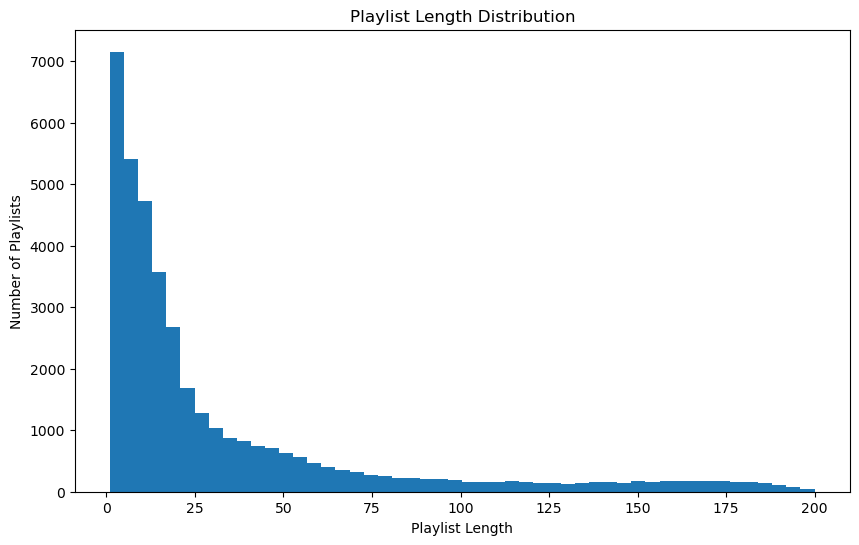

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(playlist_lengths, bins=50)
plt.xlabel("Playlist Length")
plt.ylabel("Number of Playlists")
plt.title("Playlist Length Distribution")
plt.show()

In [11]:
all_tracks = [track for playlist in train_data for track in playlist]

In [12]:
counterDict = Counter(all_tracks)
for k,v in list(counterDict.items())[:5]:
    print(k, v)

nitzer ebb__i give to you 9
nitzer ebb__come alive 2
nachtmahr__feuer frei 10
the last dance__once beautiful 3
clint mansell__the last man 19


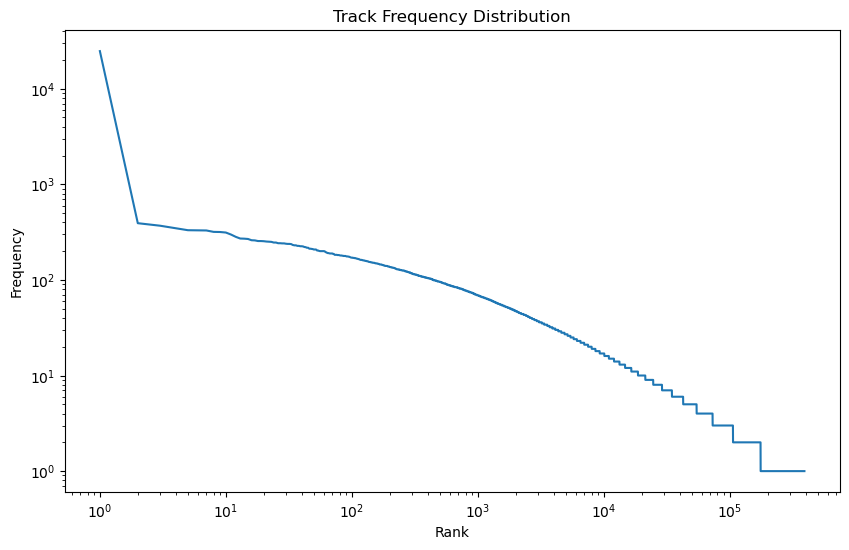

In [13]:
freqs = [count for _, count in counterDict.most_common()]
ranks = range(1, len(freqs) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, freqs)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Track Frequency Distribution")
plt.show()

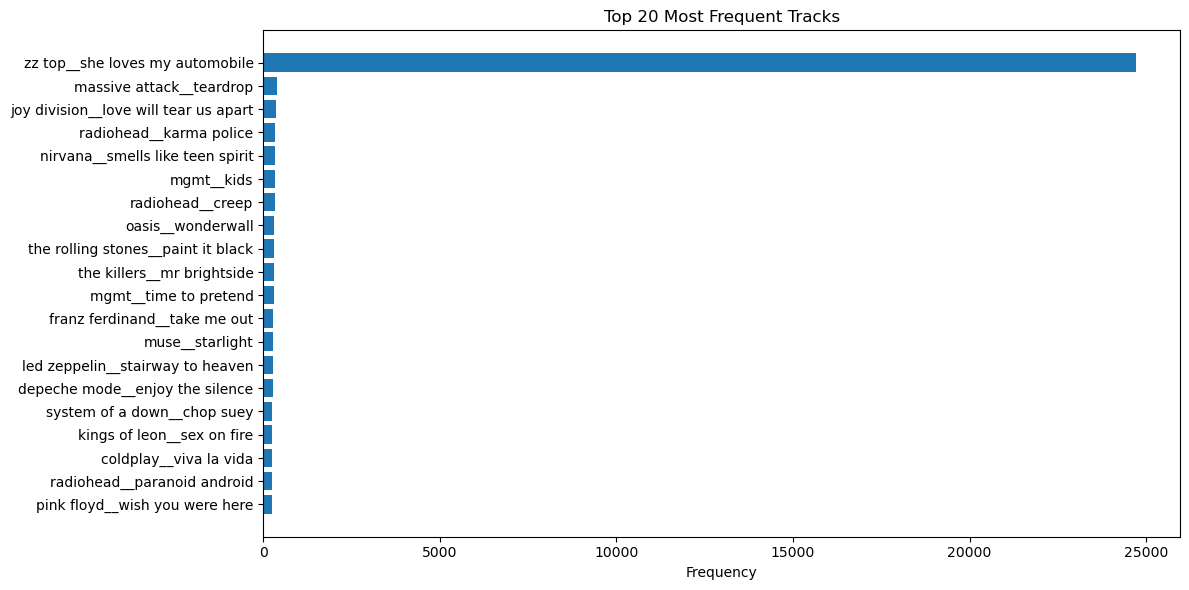

In [14]:
top20_tracks = counterDict.most_common(20)
tracks, counts = zip(*top20_tracks)

plt.figure(figsize=(12, 6))
plt.barh(tracks, counts)
plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Tracks")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
top20_tracks = counterDict.most_common(20)

print("Top 20 Most Frequent Tracks:")
for i, (track, count) in enumerate(top20_tracks, 1):
    print(f"{i}. {track} → {count}")

Top 20 Most Frequent Tracks:
1. zz top__she loves my automobile → 24721
2. massive attack__teardrop → 392
3. joy division__love will tear us apart → 369
4. radiohead__karma police → 347
5. nirvana__smells like teen spirit → 331
6. mgmt__kids → 330
7. radiohead__creep → 329
8. oasis__wonderwall → 318
9. the rolling stones__paint it black → 317
10. the killers__mr brightside → 313
11. mgmt__time to pretend → 298
12. franz ferdinand__take me out → 282
13. muse__starlight → 271
14. led zeppelin__stairway to heaven → 270
15. depeche mode__enjoy the silence → 268
16. system of a down__chop suey → 260
17. kings of leon__sex on fire → 259
18. coldplay__viva la vida → 255
19. radiohead__paranoid android → 255
20. pink floyd__wish you were here → 254


In [16]:
total_unique = len(counterDict)
hapax = sum(1 for count in counterDict.values() if count == 1)
coverage = hapax / total_unique * 100

print(f"Total unique tracks: {total_unique}")
print(f"Hapax legomena (appearing only once): {hapax}")
print(f"Coverage (hapax / total): {coverage:.2f}%")

Total unique tracks: 391991
Hapax legomena (appearing only once): 216260
Coverage (hapax / total): 55.17%


In [25]:
baseModel = Word2Vec (
    sentences=train_data,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    ns_exponent=0.75,
    workers=4,
    epochs=5
)

In [85]:
def ContextAveraging(model, k=10):
    total_score = 0
    total_trial = 0
    total_ncdg = 0
    for sentence in test_data:
        total_embedding = 0
        count = 0
        lastSong = sentence[-1]
        calculatorSentence = sentence[:-1]
        for song in calculatorSentence:
            if song in model.wv:
                total_embedding += model.wv[song]
                count += 1
        if lastSong not in model.wv:
            continue
        if count == 0:
            continue
        avg_embedding = total_embedding / count
        predictionList = model.wv.most_similar(positive=[avg_embedding], topn=k)
        songList = [song for song, score in predictionList]
        if lastSong in songList:
            total_score += 1
            rank = songList.index(lastSong) + 1
            total_ncdg += 1 / math.log2(rank+1)
        total_trial += 1
    predictionRateHR = total_score / total_trial
    predictionRateNDCG = total_ncdg / total_trial
    return predictionRateHR, predictionRateNDCG
            
print(ContextAveraging(baseModel))

(0.026797984425103068, 0.019943111572830116)


In [86]:
def SingleQuerySong(model, k=10):
    total_score = 0
    total_trial = 0
    total_ncdg = 0
    for sentence in test_data:
        if len(sentence) < 2:
            continue
        lastSong = sentence[-1]
        secondLastSong = sentence[-2]
        if lastSong not in model.wv or secondLastSong not in model.wv:
            continue
        secondLastSongEmbedding = model.wv[secondLastSong]
        predictionList = model.wv.most_similar(positive=[secondLastSongEmbedding], topn=k)
        songList = [song for song, score in predictionList]
        if lastSong in songList:
            total_score += 1
            rank = songList.index(lastSong) + 1
            total_ncdg += 1 / math.log2(rank+1)
        total_trial += 1
    predictionRateHR = total_score / total_trial
    predictionRateNDCG = total_ncdg / total_trial
    return predictionRateHR, predictionRateNDCG

print(SingleQuerySong(baseModel))

(0.04147786685256187, 0.02431671134843077)


In [ ]:
def BestModelForEpochs():
    epoch_values = [5, 20, 50]
    results = {}

    for epoch in epoch_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=100,
            window=5,
            min_count=5,
            sg=1,
            negative=5,
            ns_exponent=0.75,
            workers=4,
            epochs=epoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[epoch] = result

    for epoch in results:
        result = results[epoch]
        print(f"epoch={epoch}: HR={result:.4f}")
        if result == max(results.values()):
            return epoch

bestEpoch = BestModelForEpochs()

epoch=5: HR=0.0408
epoch=20: HR=0.0673
epoch=50: HR=0.0683


50

In [35]:
def BestModelForNsExponent():
    ns_exponent_values = [-1.0, -0.5, 0, 0.5, 0.75, 1.0]
    results = {}


    for ns_exponent in ns_exponent_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=100,
            window=5,
            min_count=5,
            sg=1,
            negative=5,
            ns_exponent=ns_exponent,
            workers=4,
            epochs=bestEpoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[ns_exponent] = result 

    for ns_exponent in results:
        result = results[ns_exponent]
        print(f"ns_exponent={ns_exponent}: HR={result:.4f}")
        if results[ns_exponent] == max(results.values()):
            return ns_exponent

bestNs = BestModelForNsExponent()
bestNs

ns_exponent=-1.0: HR=0.0732
ns_exponent=-0.5: HR=0.0749


-0.5

In [36]:
def BestModelForWindow():
    window_values = [5, 20, 40]
    results = {}

    for window in window_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=100,
            window=window,
            min_count=5,
            sg=1,
            negative=5,
            ns_exponent=bestNs,
            workers=4,
            epochs=bestEpoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[window] = result

    for window in results:
        result = results[window]
        print(f"window={window}: HR={result:.4f}")
        if result == max(results.values()):
            return window
        
bestWindow = BestModelForWindow()
bestWindow

window=5: HR=0.0760
window=20: HR=0.0864
window=40: HR=0.0892


40

In [39]:
def BestModelForNegative():
    negative_values = [5, 10, 15]
    results = {}

    for negative in negative_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=100,
            window=bestWindow,
            min_count=5,
            sg=1,
            negative=negative,
            ns_exponent=bestNs,
            workers=4,
            epochs=bestEpoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[negative] = result

    for negative in negative_values:
        result = results[negative]
        print(f"negative={negative}: HR={result:.4f}")
        if result == max(results.values()):
            return negative
        
bestNegative = BestModelForNegative()
bestNegative

negative=5: HR=0.0885
negative=10: HR=0.0927
negative=15: HR=0.0938


15

In [40]:
def BestModelForMinCount():
    min_count_values = [3, 5, 10]
    results = {}

    for min_count in min_count_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=100,
            window=bestWindow,
            min_count=min_count,
            sg=1,
            negative=bestNegative,
            ns_exponent=bestNs,
            workers=4,
            epochs=bestEpoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[min_count] = result

    for min_count in min_count_values:
        result = results[min_count]
        print(f"min_count={min_count}: HR={result:.4f}")
        if result == max(results.values()):
            return min_count
        
bestMinCount = BestModelForMinCount()
bestMinCount 

min_count=3: HR=0.0702
min_count=5: HR=0.0979
min_count=10: HR=0.1342


10

In [44]:
def BestModelForVectorSize():
    vector_size_values = [50, 100, 300]
    results = {}

    for vector_size in vector_size_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=vector_size,
            window=bestWindow,
            min_count=bestMinCount,
            sg=1,
            negative=bestNegative,
            ns_exponent=bestNs,
            workers=4,
            epochs=bestEpoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[vector_size] = result

    maxVectorSize = 0
    for vector_size in vector_size_values:
        result = results[vector_size]
        print(f"vector_size={vector_size}: HR={result:.4f}")
        if result == max(results.values()):
            maxVectorSize = vector_size
    return maxVectorSize
        
bestVectorSize = BestModelForVectorSize()
bestVectorSize 

vector_size=50: HR=0.1291
vector_size=100: HR=0.1359
vector_size=300: HR=0.1319


100

In [45]:
def BestModelForSg():
    sg_values = [0, 1]
    results = {}

    for sg in sg_values:
        model_temp = Word2Vec(
            sentences=train_data,
            vector_size=bestVectorSize,
            window=bestWindow,
            min_count=bestMinCount,
            sg=sg,
            negative=bestNegative,
            ns_exponent=bestNs,
            workers=4,
            epochs=bestEpoch
        )

        result = SingleQuerySong(model_temp)[0]
        results[sg] = result

    maxSg = 0
    for sg in sg_values:
        result = results[sg]
        print(f"sg={sg}: HR={result:.4f}")
        if result == max(results.values()):
            maxSg = sg
    return maxSg
        
bestSg = BestModelForSg()
bestSg 

sg=0: HR=0.1140
sg=1: HR=0.1331


1

In [46]:
final_model = Word2Vec(
    sentences=train_data,
    vector_size=bestVectorSize,
    window=bestWindow,
    min_count=bestMinCount,
    sg=bestSg,
    negative=bestNegative,
    ns_exponent=bestNs,
    workers=4,
    epochs=bestEpoch
)

In [51]:
# APPROACH 2
print("APPROACH-2")
for k in [5, 10, 20, 50]:
    hr, ndcg = SingleQuerySong(final_model, k=k)
    print(f"K={k}: HR={hr:.4f}, NDCG={ndcg:.4f}")

APPROACH-2
K=5: HR=0.0938, NDCG=0.0573
K=10: HR=0.1303, NDCG=0.0689
K=20: HR=0.1814, NDCG=0.0818
K=50: HR=0.2364, NDCG=0.0928


In [52]:
# APPROACH 1
print("APPROACH-1")
for k in [5, 10, 20, 50]:
    hr, ndcg = ContextAveraging(final_model, k=k)
    print(f"K={k}: HR={hr:.4f}, NDCG={ndcg:.4f}")

APPROACH-1
K=5: HR=0.0653, NDCG=0.0448
K=10: HR=0.1044, NDCG=0.0573
K=20: HR=0.1479, NDCG=0.0683
K=50: HR=0.2206, NDCG=0.0828


In [55]:
similar = final_model.wv.most_similar("queen__bohemian rhapsody", topn=10)
for song, score in similar:
    print(f"{song}: {score:.4f}")

queen__we will rock you: 0.8262
queen__we are the champions: 0.7578
queen__don't stop me now: 0.7417
queen__killer queen: 0.7399
queen__somebody to love: 0.7296
queen__another one bites the dust: 0.7272
queen__the show must go on: 0.7105
queen__bicycle race: 0.6945
led zeppelin__stairway to heaven: 0.6934
queen__i want to break free: 0.6880


In [57]:
similar = final_model.wv.most_similar("led zeppelin__stairway to heaven", topn=10)
for song, score in similar:
    print(f"{song}: {score:.4f}")

led zeppelin__whole lotta love: 0.8097
led zeppelin__immigrant song: 0.7718
led zeppelin__kashmir: 0.7619
deep purple__smoke on the water: 0.7553
led zeppelin__black dog: 0.7469
pink floyd__wish you were here: 0.7466
led zeppelin__since i've been loving you: 0.7168
pink floyd__comfortably numb: 0.7073
queen__bohemian rhapsody: 0.6934
led zeppelin__dazed and confused: 0.6848


In [58]:
similar = final_model.wv.most_similar("michael jackson__thriller", topn=10)
for song, score in similar:
    print(f"{song}: {score:.4f}")

michael jackson__beat it: 0.8691
michael jackson__bad: 0.8649
michael jackson__billie jean: 0.8445
michael jackson__smooth criminal: 0.8199
michael jackson__black or white: 0.7903
michael jackson__man in the mirror: 0.7705
michael jackson__the way you make me feel: 0.7360
michael jackson__rock with you: 0.7324
michael jackson__dirty diana: 0.7173
michael jackson__wanna be startin' somethin': 0.7036


In [61]:
similar = final_model.wv.most_similar("pink floyd__wish you were here", topn=10)
for song, score in similar:
    print(f"{song}: {score:.4f}")

pink floyd__comfortably numb: 0.8690
pink floyd__hey you: 0.8272
pink floyd__time: 0.7797
pink floyd__money: 0.7578
pink floyd__us and them: 0.7558
led zeppelin__stairway to heaven: 0.7466
pink floyd__high hopes: 0.7439
pink floyd__the great gig in the sky: 0.7374
pink floyd__shine on you crazy diamond: 0.7184
pink floyd__welcome to the machine: 0.7057


In [62]:
similar = final_model.wv.most_similar("nirvana__smells like teen spirit", topn=10)
for song, score in similar:
    print(f"{song}: {score:.4f}")

nirvana__come as you are: 0.8906
nirvana__lithium: 0.8588
nirvana__rape me: 0.8286
nirvana__in bloom: 0.7922
nirvana__polly: 0.7451
nirvana__about a girl: 0.7361
nirvana__all apologies: 0.7234
nirvana__drain you: 0.7071
nirvana__breed: 0.6947
nirvana__dumb: 0.6946


In [63]:
final_model.wv.most_similar(
    positive=["queen__bohemian rhapsody", "led zeppelin__stairway to heaven"],
    negative=["nirvana__smells like teen spirit"]
)

[('led zeppelin__kashmir', 0.6514701247215271),
 ('pink floyd__wish you were here', 0.6090667843818665),
 ('led zeppelin__whole lotta love', 0.6061370968818665),
 ("led zeppelin__since i've been loving you", 0.5956087112426758),
 ('led zeppelin__immigrant song', 0.5918290019035339),
 ('lynyrd skynyrd__sweet home alabama', 0.585025429725647),
 ('led zeppelin__black dog', 0.5761316418647766),
 ('deep purple__smoke on the water', 0.5733107924461365),
 ('jethro tull__aqualung', 0.5726091265678406),
 ('deep purple__child in time', 0.5670084953308105)]

In [66]:
final_model.wv.most_similar(
    positive=["pink floyd__wish you were here", "led zeppelin__stairway to heaven"],
    negative=["michael jackson__thriller"]
)

[('pink floyd__comfortably numb', 0.6936275959014893),
 ('pink floyd__hey you', 0.6448172926902771),
 ('led zeppelin__kashmir', 0.6341468095779419),
 ('led zeppelin__whole lotta love', 0.6334332227706909),
 ("led zeppelin__since i've been loving you", 0.6287224888801575),
 ('deep purple__child in time', 0.6176342964172363),
 ('led zeppelin__the battle of evermore', 0.6154232025146484),
 ('pink floyd__the great gig in the sky', 0.614818811416626),
 ('pink floyd__time', 0.6062097549438477),
 ('led zeppelin__immigrant song', 0.6041151285171509)]

In [65]:
final_model.wv.most_similar(
    positive=["queen__bohemian rhapsody", "michael jackson__thriller"],
    negative=["pink floyd__wish you were here"]
)

[('michael jackson__bad', 0.7450981736183167),
 ('michael jackson__beat it', 0.7007122039794922),
 ('michael jackson__man in the mirror', 0.6976467967033386),
 ('michael jackson__billie jean', 0.6828221082687378),
 ('michael jackson__black or white', 0.6827552318572998),
 ('michael jackson__rock with you', 0.6709281802177429),
 ('michael jackson__smooth criminal', 0.6689131855964661),
 ('michael jackson__the way you make me feel', 0.662318766117096),
 ("michael jackson__wanna be startin' somethin'", 0.6316487193107605),
 ('michael jackson__you are not alone', 0.597048282623291)]

In [72]:
songs = []
vectors = []

for song, count in counterDict.most_common(500):
    if song in final_model.wv:
        songs.append(song)
        vectors.append(final_model.wv[song])

vectors = np.array(vectors)
print(vectors.shape)

(500, 100)


In [73]:
tsne = TSNE(n_components=2, random_state=42)
vectors_2d = tsne.fit_transform(vectors)

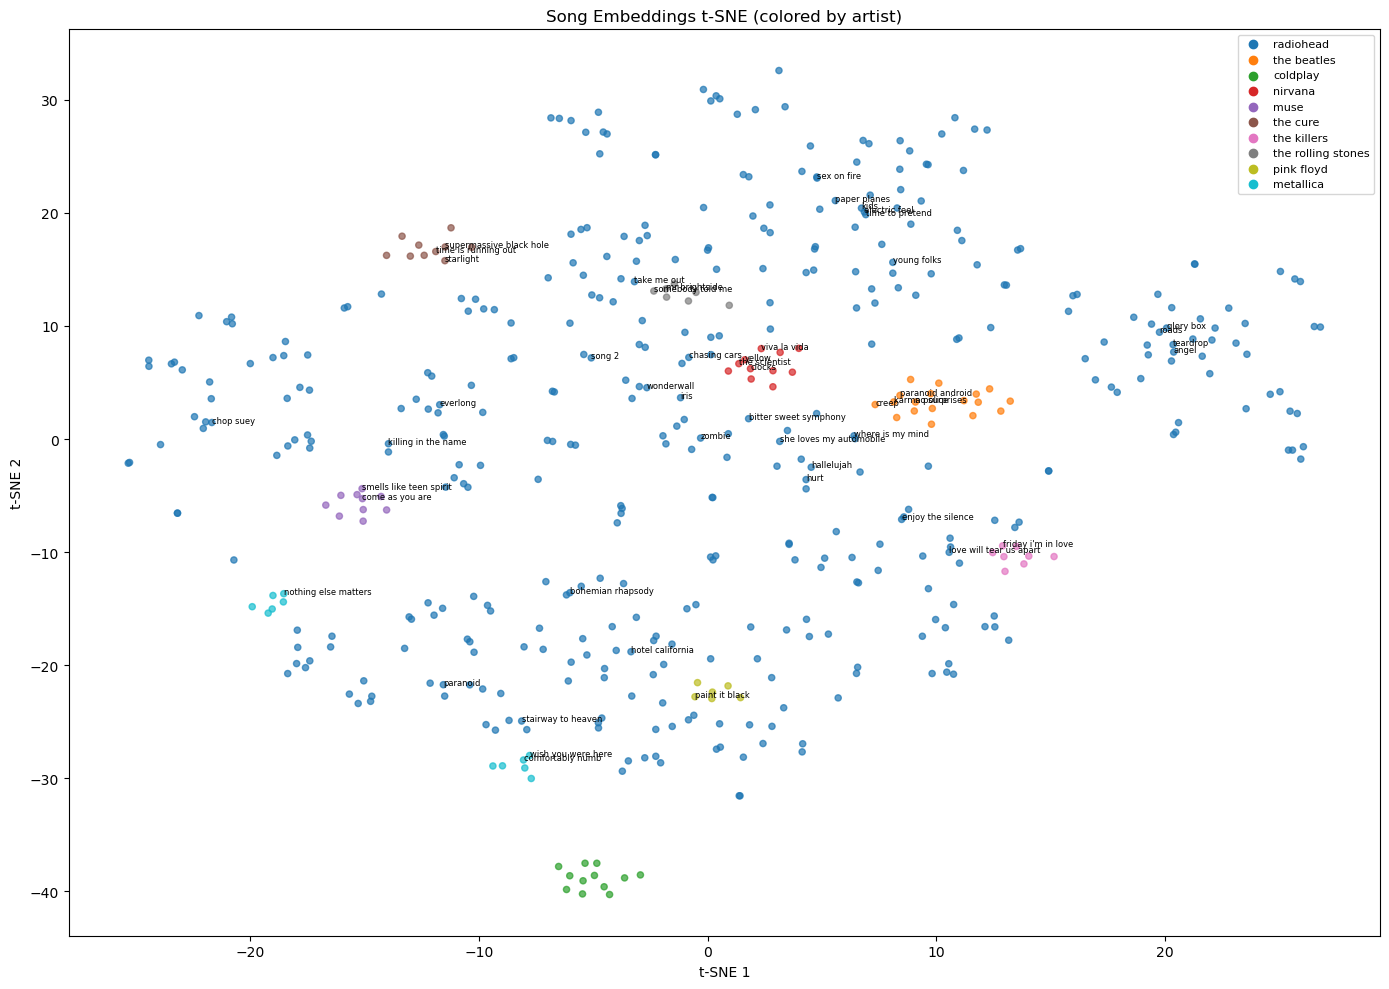

In [76]:
artists = [song.split("__")[0] for song in songs]

top_artists = [artist for artist, _ in Counter(artists).most_common(10)]

colors = []
for artist in artists:
    if artist in top_artists:
        colors.append(top_artists.index(artist))
    else:
        colors.append(-1)

plt.figure(figsize=(14, 10))
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                      c=colors, cmap='tab10', alpha=0.7, s=20)

for i, song in enumerate(songs[:50]):
    plt.annotate(song.split("__")[1], (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=6)

# Legend
for i, artist in enumerate(top_artists):
    plt.scatter([], [], c=[plt.cm.tab10(i/10)], label=artist)
plt.legend(loc='upper right', fontsize=8)

plt.title("Song Embeddings t-SNE (colored by artist)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [79]:
def RecommendSong(seed_songs, model, top_k=10):
    total_embedding = 0
    count = 0
    for song in seed_songs:
        if song in model.wv:
            total_embedding += model.wv[song]
            count += 1
    if count == 0:
        return []
    avg_embedding = total_embedding / count
    recommendations = model.wv.most_similar(positive=[avg_embedding], topn=top_k + len(seed_songs))
    rawRecommendations = [song for song, score in recommendations if song not in seed_songs]
    return rawRecommendations

seeds = ["queen__bohemian rhapsody", "led zeppelin__stairway to heaven"]
RecommendSong(seeds, final_model, top_k=10)

['deep purple__smoke on the water',
 'led zeppelin__whole lotta love',
 'queen__we will rock you',
 'led zeppelin__kashmir',
 'led zeppelin__immigrant song',
 'pink floyd__wish you were here',
 'eagles__hotel california',
 'the rolling stones__paint it black',
 'black sabbath__paranoid',
 'led zeppelin__black dog']

In [80]:
total_unique = len(counterDict)
vocab = set(final_model.wv.key_to_index.keys())
oov_total = sum(1 for track in counterDict if track not in vocab)
oov_percent = oov_total / total_unique * 100
print(f"Total unique tracks: {total_unique}")
print(f"OOV tracks: {oov_total} ({oov_percent:.2f}%)")

test_tracks = set(track for playlist in test_data for track in playlist)
oov_test = sum(1 for track in test_tracks if track not in vocab)
oov_test_percent = oov_test / len(test_tracks) * 100
print(f"Test set unique tracks: {len(test_tracks)}")
print(f"OOV in test set: {oov_test} ({oov_test_percent:.2f}%)")

Total unique tracks: 391991
OOV tracks: 370631 (94.55%)
Test set unique tracks: 164431
OOV in test set: 144174 (87.68%)


In [81]:
artist_embeddings = {}
for song in vocab:
    artist = song.split("__")[0]
    if artist not in artist_embeddings:
        artist_embeddings[artist] = []
    artist_embeddings[artist].append(final_model.wv[song])

artist_avg_embeddings = {}
for artist, embeddings in artist_embeddings.items():
    artist_avg_embeddings[artist] = np.mean(embeddings, axis=0)

def get_embedding_with_fallback(song, model):
    if song in model.wv:
        return model.wv[song]
    artist = song.split("__")[0]
    if artist in artist_avg_embeddings:
        return artist_avg_embeddings[artist]
    return None

In [82]:
def SingleQuerySongFiltered(model, min_count=None, max_count=None, k=10):
    total_score = 0
    total_trial = 0
    total_ndcg = 0
    for sentence in test_data:
        if len(sentence) < 2:
            continue
        lastSong = sentence[-1]
        secondLastSong = sentence[-2]
        if lastSong not in model.wv or secondLastSong not in model.wv:
            continue
        count = counterDict.get(lastSong, 0)
        if min_count and count < min_count:
            continue
        if max_count and count > max_count:
            continue
        embedding = model.wv[secondLastSong]
        predictionList = model.wv.most_similar(positive=[embedding], topn=k)
        songList = [song for song, score in predictionList]
        if lastSong in songList:
            total_score += 1
            rank = songList.index(lastSong) + 1
            total_ndcg += 1 / math.log2(rank + 1)
        total_trial += 1
    if total_trial == 0:
        return 0, 0
    return total_score / total_trial, total_ndcg / total_trial

hr_popular, ndcg_popular = SingleQuerySongFiltered(final_model, min_count=100)
hr_rare, ndcg_rare = SingleQuerySongFiltered(final_model, max_count=10)
print(f"Popular songs (>100): HR@10={hr_popular:.4f}, NDCG@10={ndcg_popular:.4f}")
print(f"Rare songs (<10): HR@10={hr_rare:.4f}, NDCG@10={ndcg_rare:.4f}")

Popular songs (>100): HR@10=0.2395, NDCG@10=0.1619
Rare songs (<10): HR@10=0.0175, NDCG@10=0.0111


In [83]:
def HR_by_playlist_length(model, k=10):
    short = {"score": 0, "trial": 0}
    medium = {"score": 0, "trial": 0}
    long = {"score": 0, "trial": 0}
    
    for sentence in test_data:
        if len(sentence) < 2:
            continue
        lastSong = sentence[-1]
        secondLastSong = sentence[-2]
        if lastSong not in model.wv or secondLastSong not in model.wv:
            continue
        
        if len(sentence) < 10:
            group = short
        elif len(sentence) <= 30:
            group = medium
        else:
            group = long
            
        embedding = model.wv[secondLastSong]
        predictionList = model.wv.most_similar(positive=[embedding], topn=k)
        songList = [song for song, score in predictionList]
        
        if lastSong in songList:
            group["score"] += 1
        group["trial"] += 1
    
    for name, group in [("Short (<10)", short), ("Medium (10-30)", medium), ("Long (>30)", long)]:
        if group["trial"] > 0:
            print(f"{name}: HR@10={group['score']/group['trial']:.4f}, n={group['trial']}")

HR_by_playlist_length(final_model)

Short (<10): HR@10=0.1262, n=618
Medium (10-30): HR@10=0.1304, n=621
Long (>30): HR@10=0.1347, n=542
